In [1]:
import cobra
import escher
import matplotlib.pyplot as plt

In [2]:
# Load the model
model = cobra.io.read_sbml_model("../../model.xml")

In [3]:
# Save the path to the Escher map (with glycolysis and TCA cycle)
amac_map_path = "../../escher/MIT1002_glycolysis_and_tca_escher-map.json"

In [4]:
# Define the medium without any carbon source
no_o2_coutilization_med = {
    "EX_cpd00027_e0": 5,  # Glucose (half the original bound)
    "EX_cpd00029_e0": 15,  # Acetate (half the original bound)
    "EX_cpd00013_e0": 1000,  # Ammonia
    "EX_cpd00058_e0": 1000,  # Cu2+_e0
    "EX_cpd00971_e0": 1000,  # Na+_e0
    "EX_cpd00063_e0": 1000,  # Ca2+_e0
    "EX_cpd00048_e0": 1000,  # Sulfate_e0
    "EX_cpd10516_e0": 1000,  # fe3_e0
    "EX_cpd00254_e0": 1000,  # Mg_e0
    "EX_cpd00009_e0": 1000,  # Phosphate_e0
    "EX_cpd00205_e0": 1000,  # K+_e0
    "EX_cpd00013_e0": 1000,  # NH3_e0
    "EX_cpd00099_e0": 1000,  # Cl-_e0
    "EX_cpd00030_e0": 1000,  # Mn2+_e0
    "EX_cpd00001_e0": 1000,  # H2O_e0
    "EX_cpd00034_e0": 1000,  # Zn2+_e0
    "EX_cpd00149_e0": 1000,  # Co2+_e0
}

In [5]:
# Make a version of the medium with "low" oxygen (10)
o2_10_med = no_o2_coutilization_med.copy()
o2_10_med["EX_cpd00007_e0"] = 10  # O2_e0

In [6]:
# Make a version of the medium with "standard" oxygen (20)
o2_20_med = no_o2_coutilization_med.copy()
o2_20_med["EX_cpd00007_e0"] = 20  # O2_e0

In [7]:
# Make a version of the medium with "unlimited" oxygen (1000)
o2_unlimited_med = no_o2_coutilization_med.copy()
o2_unlimited_med["EX_cpd00007_e0"] = 1000  # O2_e0

In [8]:
# Run pFBA on the low oxygen medium and make Escher map
model.medium = o2_10_med
pfba_solution = cobra.flux_analysis.pfba(model)
# Make map with the pFBA solution
builder = escher.Builder(
    model=model, map_json=amac_map_path
)
builder.reaction_data = pfba_solution.fluxes
builder
# Then save the map manually from the widget

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


Builder(reaction_data={'rxn02201_c0': 0.0021704426933847297, 'rxn00351_c0': 0.0, 'rxn07431_c0': 0.0, 'rxn00836…

In [9]:
# Run pFBA on the standard oxygen medium and make Escher map
model.medium = o2_20_med
pfba_solution = cobra.flux_analysis.pfba(model)
# Make map with the pFBA solution
builder = escher.Builder(
    model=model, map_json=amac_map_path
)
builder.reaction_data = pfba_solution.fluxes
builder
# Then save the map manually from the widget

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


Builder(reaction_data={'rxn02201_c0': 0.00310510268257607, 'rxn00351_c0': 0.0, 'rxn07431_c0': 0.0, 'rxn00836_c…

In [10]:
# Run pFBA on the unlimited oxygen medium and make Escher map
model.medium = o2_unlimited_med
pfba_solution = cobra.flux_analysis.pfba(model)
# Make map with the pFBA solution
builder = escher.Builder(
    model=model, map_json=amac_map_path
)
builder.reaction_data = pfba_solution.fluxes
builder
# Then save the map manually from the widget

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


Builder(reaction_data={'rxn02201_c0': 0.0036429629796064585, 'rxn00351_c0': 0.0, 'rxn07431_c0': 0.0, 'rxn00836…

In [11]:
# Run pfBA on a range of oxygen levels and record grwoth rates, and exchanges
o2_levels = range(10, 31)
growth_rates = []
glc_exchanges = []
acetate_exchanges = []
for o2 in o2_levels:
    # Make the medium with the given oxygen level
    medium = no_o2_coutilization_med.copy()
    medium["EX_cpd00007_e0"] = o2  # O2_e0
    model.medium = medium
    # Run pFBA
    pfba_solution = cobra.flux_analysis.pfba(model)
    # Record growth rate and exchanges
    growth_rates.append(pfba_solution.fluxes["bio1_biomass"])
    glc_exchanges.append(pfba_solution.fluxes["EX_cpd00027_e0"])
    acetate_exchanges.append(pfba_solution.fluxes["EX_cpd00029_e0"])

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.
Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.
Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.
Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.
Could not identify an external compartment by name and choosing one with the mos

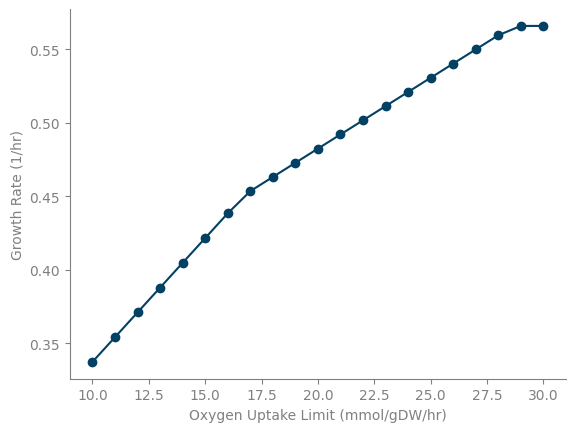

In [12]:
# Make a line graph of growth rate vs oxygen level
plt.plot(o2_levels, growth_rates, marker='o', color="#024064")
plt.xlabel("Oxygen Uptake Limit (mmol/gDW/hr)", color="gray")
plt.ylabel("Growth Rate (1/hr)", color="gray")

# TODO: Use plot style file instead of manual styling
# Make the axis lines gray
plt.gca().spines["bottom"].set_color("gray")
plt.gca().spines["left"].set_color("gray")
# Make the tick marks gray
plt.gca().tick_params(axis="x", colors="gray")
plt.gca().tick_params(axis="y", colors="gray")
# Remove the top and right axis lines
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

In [13]:
glc_exchanges

[-5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0,
 -5.0]

In [14]:
acetate_exchanges

[2.1829440552513724,
 1.2920912580145796,
 0.4012384607773442,
 -0.4896143364601779,
 -1.3804671336977679,
 -2.271319930937474,
 -3.1621727281684766,
 -4.0668240626941845,
 -5.004416064028477,
 -5.942008065362458,
 -6.879600066696065,
 -7.817192068032945,
 -8.754784069364772,
 -9.692376070698566,
 -10.629968072032545,
 -11.567560073366398,
 -12.505152074700234,
 -13.442744076033884,
 -14.380336077367819,
 -15.00000000000215,
 -15.000000000002006]

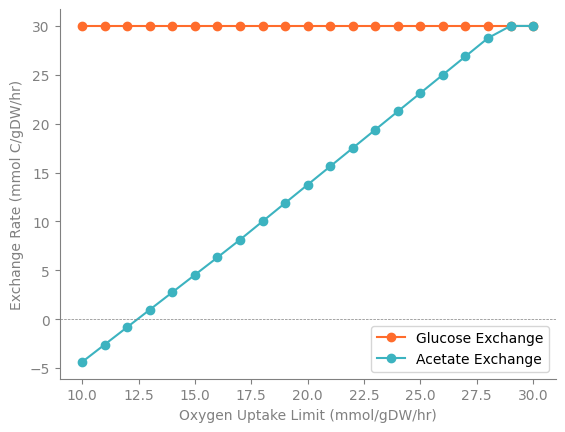

In [15]:
# Plot a line graph of the glucose and acetate uptake rates vs oxygen level
plt.plot(o2_levels, [-6 * glc for glc in glc_exchanges], marker='o', label="Glucose Exchange", color="#FF6C2C")
plt.plot(o2_levels, [-2 * ace for ace in acetate_exchanges], marker='o', label="Acetate Exchange", color="#3CB3C0")
# Add a dashed line at y=0
plt.axhline(0, color="gray", linestyle="--", linewidth=0.5)

plt.xlabel("Oxygen Uptake Limit (mmol/gDW/hr)", color="gray")
plt.ylabel("Exchange Rate (mmol C/gDW/hr)", color="gray")
plt.legend()
# TODO: Use plot style file instead of manual styling
# Make the axis lines gray
plt.gca().spines["bottom"].set_color("gray")
plt.gca().spines["left"].set_color("gray")
# Make the tick marks gray
plt.gca().tick_params(axis="x", colors="gray")
plt.gca().tick_params(axis="y", colors="gray")
# Remove the top and right axis lines
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)